In [1]:
##### Overlays capital and labor and income (overall and conservation priorities)

from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import rioxarray
from scipy.signal import savgol_filter
import rasterio
import rasterio.features
from rasterio.enums import Resampling

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# GDP pc percentile rasters
GDP_pc_percentiles_national = f"{cd}/Data/Clean/GDP_percentiles/GDP_pc_percentiles_reprojected.tif"
GDP_pc_percentiles_global = f"{cd}/Data/Clean/GDP_percentiles/global_GDP_pc_percentiles_reprojected.tif"

rd_percentiles_national = f"{cd}/Data/Clean/GDP_percentiles/relative_deprevation_percentiles_reprojected.tif"
rd_percentiles_global = f"{cd}/Data/Clean/GDP_percentiles/global_relative_deprevation_percentiles_reprojected.tif"

# priority rasters
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

In [3]:
##### Load + align rasters

capital_da         = rioxarray.open_rasterio(capital, masked=True)
capital_avg_da      = rioxarray.open_rasterio(capital_country_avg, masked=True)
labor_da            = rioxarray.open_rasterio(labor, masked=True)
labor_avg_da        = rioxarray.open_rasterio(labor_country_avg, masked=True)
gdp_pc_national_da  = rioxarray.open_rasterio(GDP_pc_percentiles_national, masked=True)
gdp_pc_global_da    = rioxarray.open_rasterio(GDP_pc_percentiles_global, masked=True)
rd_national_da  = rioxarray.open_rasterio(rd_percentiles_national, masked=True)
rd_global_da    = rioxarray.open_rasterio(rd_percentiles_global, masked=True)
biodiversity_da     = rioxarray.open_rasterio(biodiversity_with_PA, masked=True)
production_da       = rioxarray.open_rasterio(production, masked=True)

def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital_da       = match_grid(capital_da, gdp_pc_national_da)
capital_avg_da   = match_grid(capital_avg_da, gdp_pc_national_da)
labor_da         = match_grid(labor_da, gdp_pc_national_da)
labor_avg_da     = match_grid(labor_avg_da, gdp_pc_national_da)
gdp_pc_global_da = match_grid(gdp_pc_global_da, gdp_pc_national_da)
rd_global_da = match_grid(rd_global_da, rd_national_da)
biodiversity_da  = match_grid(biodiversity_da, gdp_pc_national_da)
production_da    = match_grid(production_da, gdp_pc_national_da)

percentile_lookup = {'national': gdp_pc_national_da, 'global': gdp_pc_global_da}
percentile_lookup_rd = {'national': rd_national_da, 'global': rd_global_da}


In [4]:
##### Define key functions

def pct_by_percentile_within_mask(var_da, pctl_da, priority_mask):
    """% of the mask total for var, broken out by GDP-pc percentile (1-100)."""
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = (~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
             & priority_mask)

    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100 if total > 0 else grouped


def smooth(series, window=9, polyorder=2):
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)


COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#6B7280",
}

country_mask_cache = {}

def get_country_mask(gid0, target_da=gdp_pc_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask


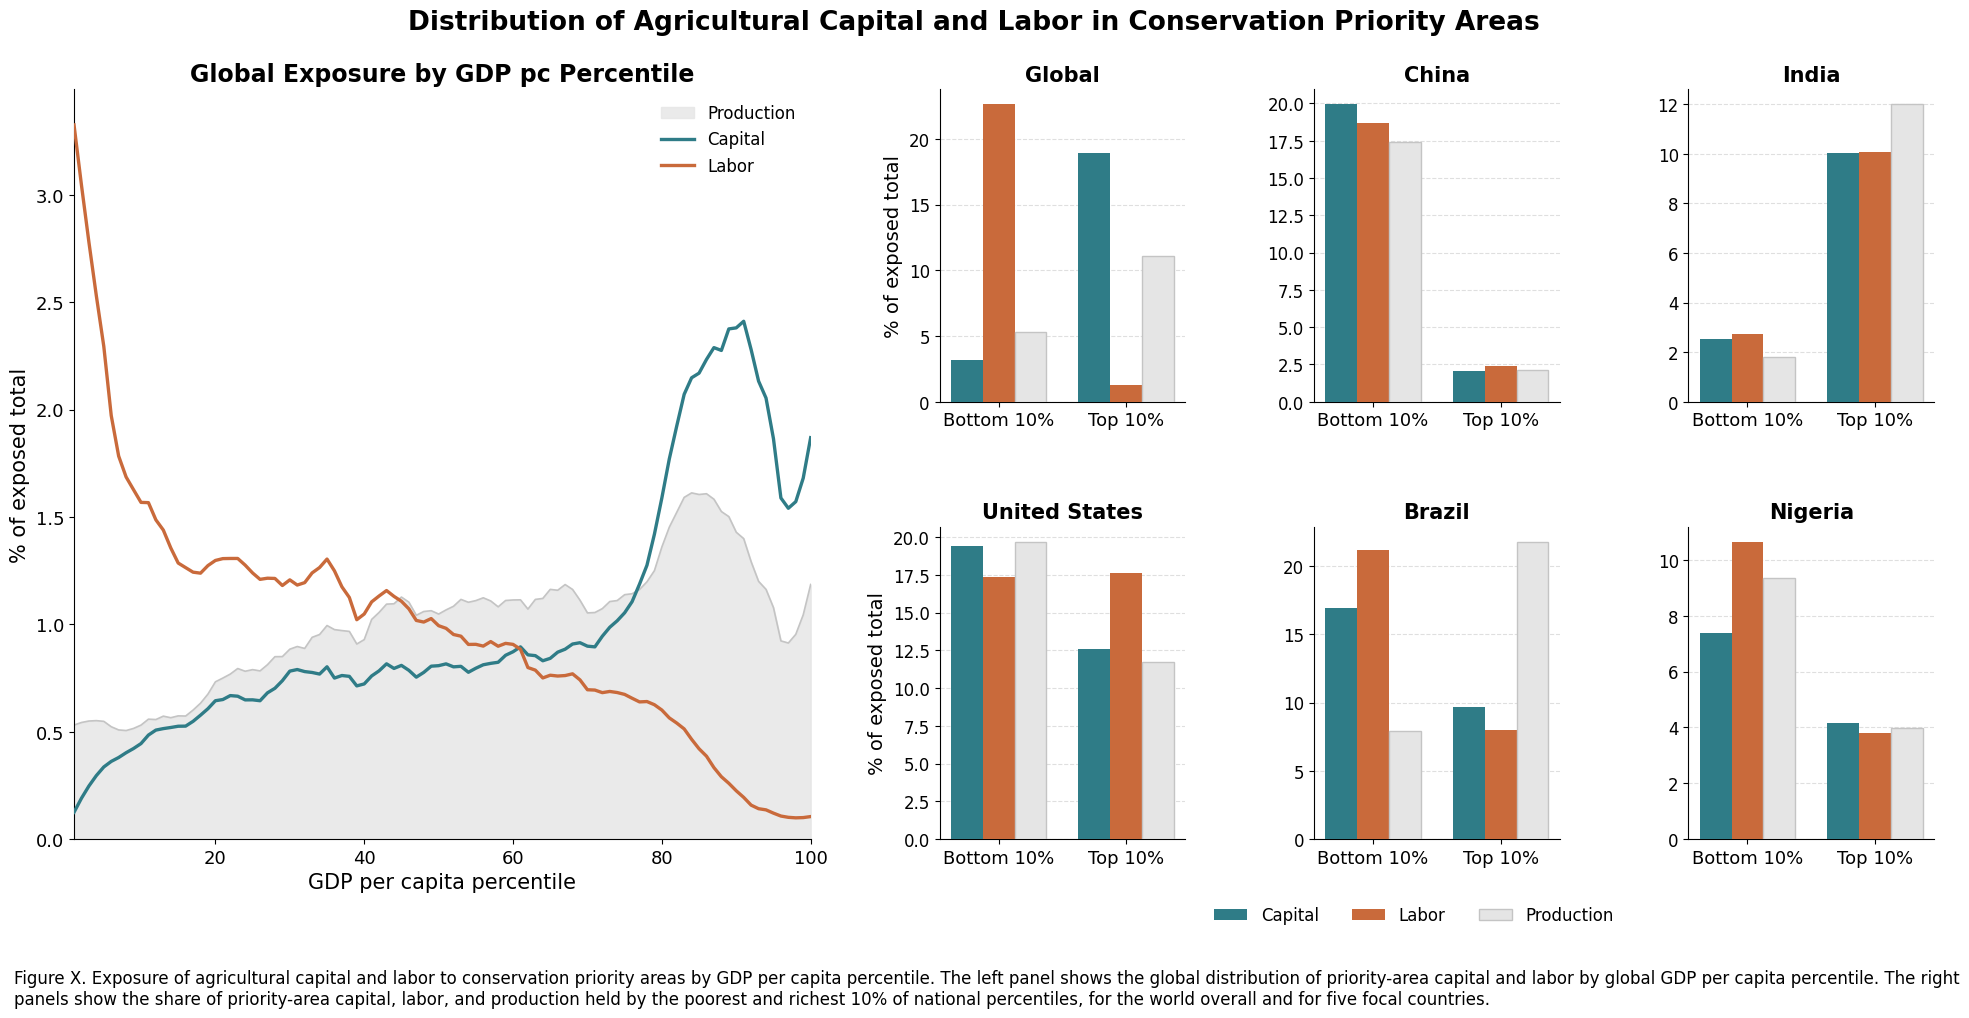

In [5]:
##### Plot exposure to capital/labor in priority areas by income percentile (no country average)
# country average infered for each country by where produciton is

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"

country_mask_cache = {}

def get_country_mask(gid0, target_da=gdp_pc_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask

##### Plot exposure to capital/labor in priority areas by income percentile

def plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names=None,     # optional dict, e.g. {"CHN": "China", "IND": "India", ...}
    global_percentile_scope='global',
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    priority_da = biodiversity_da
    priority_mask_full = priority_da.squeeze().values >= 1

    def build_mask(gid0=None):
        mask = get_country_mask(gid0) if gid0 is not None else np.ones_like(priority_mask_full, dtype=bool)
        mask = mask & priority_mask_full
        return mask

    percentile_groups = {
        "Bottom 10%": range(1, 11),
        "Top 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontweight="bold", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 4, width_ratios=[3, 1, 1, 1], wspace=0.35, hspace=0.4)

    # ---- Left: global-percentile exposure, capital + labor (line chart) ----
    ax_left = fig.add_subplot(gs[:, 0])

    pctl_da_global = percentile_lookup[global_percentile_scope]
    mask_global = build_mask(gid0=None)

    capital_pct_line     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global))
    labor_pct_line       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global))
    production_pct_line  = smooth(pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global))

    ax_left.fill_between(
        production_pct_line.index, production_pct_line.values,
        color=COLORS["Production"], alpha=0.8, zorder=1, label="Production",
    )
    ax_left.plot(
        production_pct_line.index, production_pct_line.values,
        color=PRODUCTION_EDGE, linewidth=1.2, zorder=2,
    )

    ax_left.plot(capital_pct_line.index, capital_pct_line.values, label="Capital",
                 color=COLORS["Capital"], linewidth=2.4, zorder=4)
    ax_left.plot(labor_pct_line.index, labor_pct_line.values, label="Labor",
                 color=COLORS["Labor"], linewidth=2.4, zorder=4)

    ax_left.set_xlabel(f"GDP per capita percentile", fontsize=15)
    ax_left.set_ylabel("% of exposed total", fontsize=15)
    ax_left.set_ylim(bottom=0)
    ax_left.set_xlim(1, 100)
    ax_left.tick_params(axis="both", labelsize=13)
    ax_left.spines[["top", "right"]].set_visible(False)
    ax_left.set_title(f"Global Exposure by GDP pc Percentile", fontweight="bold", fontsize=17)
    ax_left.legend(frameon=False, fontsize=12)

    # ---- Right: 2x3 grid — global panel + 5 country panels, bottom/top 10% bars ----
    right_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
    ]

    pctl_da_country = percentile_lookup[country_percentile_scope]

    # -- Global panel: bars = modeled capital/labor/production --
    ax_global = right_axes[0]

    capital_pct     = pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global)
    labor_pct       = pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global)
    production_pct  = pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global)

    capital_vals     = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    labor_vals       = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    production_vals  = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

    ax_global.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3)
    ax_global.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3)
    ax_global.bar(x + width, production_vals, width, color=COLORS["Production"],
                  edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3)
    ax_global.set_xticks(x)
    ax_global.set_xticklabels(group_names, fontsize=13)
    ax_global.tick_params(axis="y", labelsize=12)
    ax_global.set_title("Global", fontweight="bold", fontsize=15)
    ax_global.spines[["top", "right"]].set_visible(False)
    ax_global.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax_global.set_axisbelow(True)

    # -- Country panels: bars = modeled capital/labor/production --
    for ax, gid0 in zip(right_axes[1:], countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    for ax in [right_axes[0], right_axes[3]]:
        ax.set_ylabel("% of exposed total", fontsize=14)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.72, 0.05), frameon=False, fontsize=12)

    fig.suptitle(f"Distribution of Agricultural Capital and Labor in Conservation Priority Areas",
                 fontweight="bold", fontsize=19, y=0.98)

    fig.text(
        0.02,
        0.02,
        "Figure X. Exposure of agricultural capital and labor to conservation priority areas by "
        "GDP per capita percentile. The left panel shows the global distribution of priority-area capital "
        "and labor by global GDP per capita percentile. The right panels show the share of priority-area "
        "capital, labor, and production held by the poorest and richest 10% of national percentiles, for "
        "the world overall and for five focal countries.",
        ha="left",
        va="top",
        fontsize=12,
        wrap=True,
    )

    fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.15, wspace=0.35, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/exposure_priority.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot
plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names={"CHN": "China", "IND": "India", "USA": "United States", "BRA": "Brazil", "NGA": "Nigeria"},
);

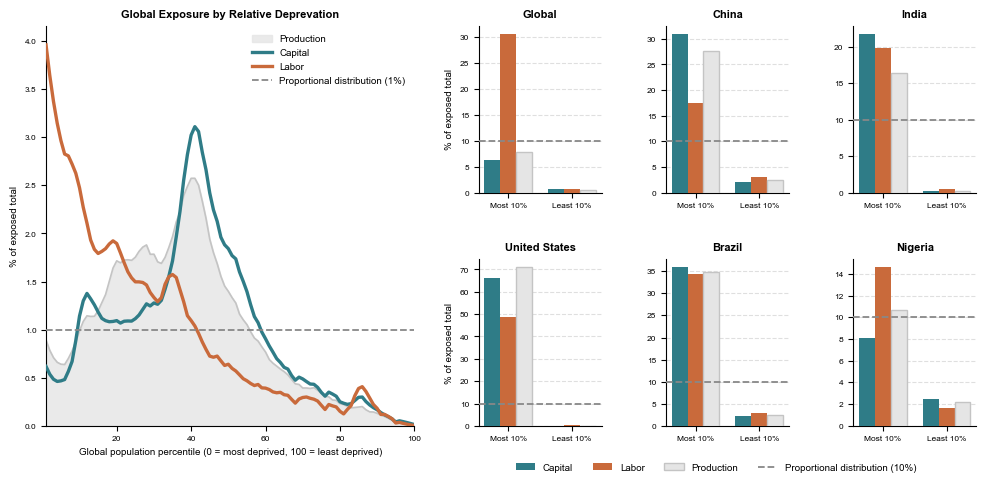

In [10]:
##### Plot exposure to capital/labor in priority areas by relative deprevation percentile (no country average)
# country average infered for each country by where produciton is

# set stype
TITLE_FS = 8   # panel titles
LABEL_FS = 7   # axis labels, legend
TICK_FS = 6    # tick labels

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": TICK_FS,
    "axes.titlesize": TITLE_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LABEL_FS,
})

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"
REFERENCE_COLOR = "#888888"

country_mask_cache = {}

def get_country_mask(gid0, target_da=rd_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask

##### Plot exposure to capital/labor in priority areas by income percentile

def plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names=None,     # optional dict, e.g. {"CHN": "China", "IND": "India", ...}
    global_percentile_scope='global',
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    priority_da = biodiversity_da
    priority_mask_full = priority_da.squeeze().values >= 1

    def build_mask(gid0=None):
        mask = get_country_mask(gid0) if gid0 is not None else np.ones_like(priority_mask_full, dtype=bool)
        mask = mask & priority_mask_full
        return mask

    percentile_groups = {
        "Most 10%": range(1, 11),
        "Least 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")
        ax.axhline(10, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=TICK_FS)
        ax.tick_params(axis="y", labelsize=TICK_FS)
        ax.set_title(title, fontweight="bold", fontsize=TITLE_FS)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig = plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(2, 4, width_ratios=[3, 1, 1, 1], wspace=0.35, hspace=0.4)

    # ---- Left: global-percentile exposure, capital + labor (line chart) ----
    ax_left = fig.add_subplot(gs[:, 0])

    pctl_da_global = percentile_lookup_rd[global_percentile_scope]
    mask_global = build_mask(gid0=None)

    capital_pct_line     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global))
    labor_pct_line       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global))
    production_pct_line  = smooth(pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global))

    ax_left.fill_between(
        production_pct_line.index, production_pct_line.values,
        color=COLORS["Production"], alpha=0.8, zorder=1, label="Production",
    )
    ax_left.plot(
        production_pct_line.index, production_pct_line.values,
        color=PRODUCTION_EDGE, linewidth=1.2, zorder=2,
    )

    ax_left.plot(capital_pct_line.index, capital_pct_line.values, label="Capital",
                 color=COLORS["Capital"], linewidth=2.4, zorder=4)
    ax_left.plot(labor_pct_line.index, labor_pct_line.values, label="Labor",
                 color=COLORS["Labor"], linewidth=2.4, zorder=4)
    ax_left.axhline(1, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4,
                     label="Proportional distribution (1%)")

    ax_left.set_xlabel("Global population percentile (0 = most deprived, 100 = least deprived)", fontsize=LABEL_FS)
    ax_left.set_ylabel("% of exposed total", fontsize=LABEL_FS)
    ax_left.set_ylim(bottom=0)
    ax_left.set_xlim(1, 100)
    ax_left.tick_params(axis="both", labelsize=TICK_FS)
    ax_left.spines[["top", "right"]].set_visible(False)
    ax_left.set_title("Global Exposure by Relative Deprevation", fontweight="bold", fontsize=TITLE_FS)
    ax_left.legend(frameon=False, fontsize=LABEL_FS)

    # ---- Right: 2x3 grid — global panel + 5 country panels, bottom/top 10% bars ----
    right_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
    ]

    pctl_da_country = percentile_lookup_rd[country_percentile_scope]

    # -- Global panel: bars = modeled capital/labor/production --
    ax_global = right_axes[0]

    capital_pct     = pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global)
    labor_pct       = pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global)
    production_pct  = pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global)

    capital_vals     = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    labor_vals       = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    production_vals  = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

    ax_global.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3)
    ax_global.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3)
    ax_global.bar(x + width, production_vals, width, color=COLORS["Production"],
                  edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3)
    ax_global.axhline(10, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4)
    ax_global.set_xticks(x)
    ax_global.set_xticklabels(group_names, fontsize=TICK_FS)
    ax_global.tick_params(axis="y", labelsize=TICK_FS)
    ax_global.set_title("Global", fontweight="bold", fontsize=TITLE_FS)
    ax_global.spines[["top", "right"]].set_visible(False)
    ax_global.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax_global.set_axisbelow(True)

    # -- Country panels: bars = modeled capital/labor/production --
    for ax, gid0 in zip(right_axes[1:], countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    for ax in [right_axes[0], right_axes[3]]:
        ax.set_ylabel("% of exposed total", fontsize=LABEL_FS)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
        Line2D([0], [0], color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", label="Proportional distribution (10%)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.72, 0.01), frameon=False, fontsize=LABEL_FS)

    fig.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.12, wspace=0.35, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/exposure_priority_relative_dperevation.tiff", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot
plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names={"CHN": "China", "IND": "India", "USA": "United States", "BRA": "Brazil", "NGA": "Nigeria"},
);

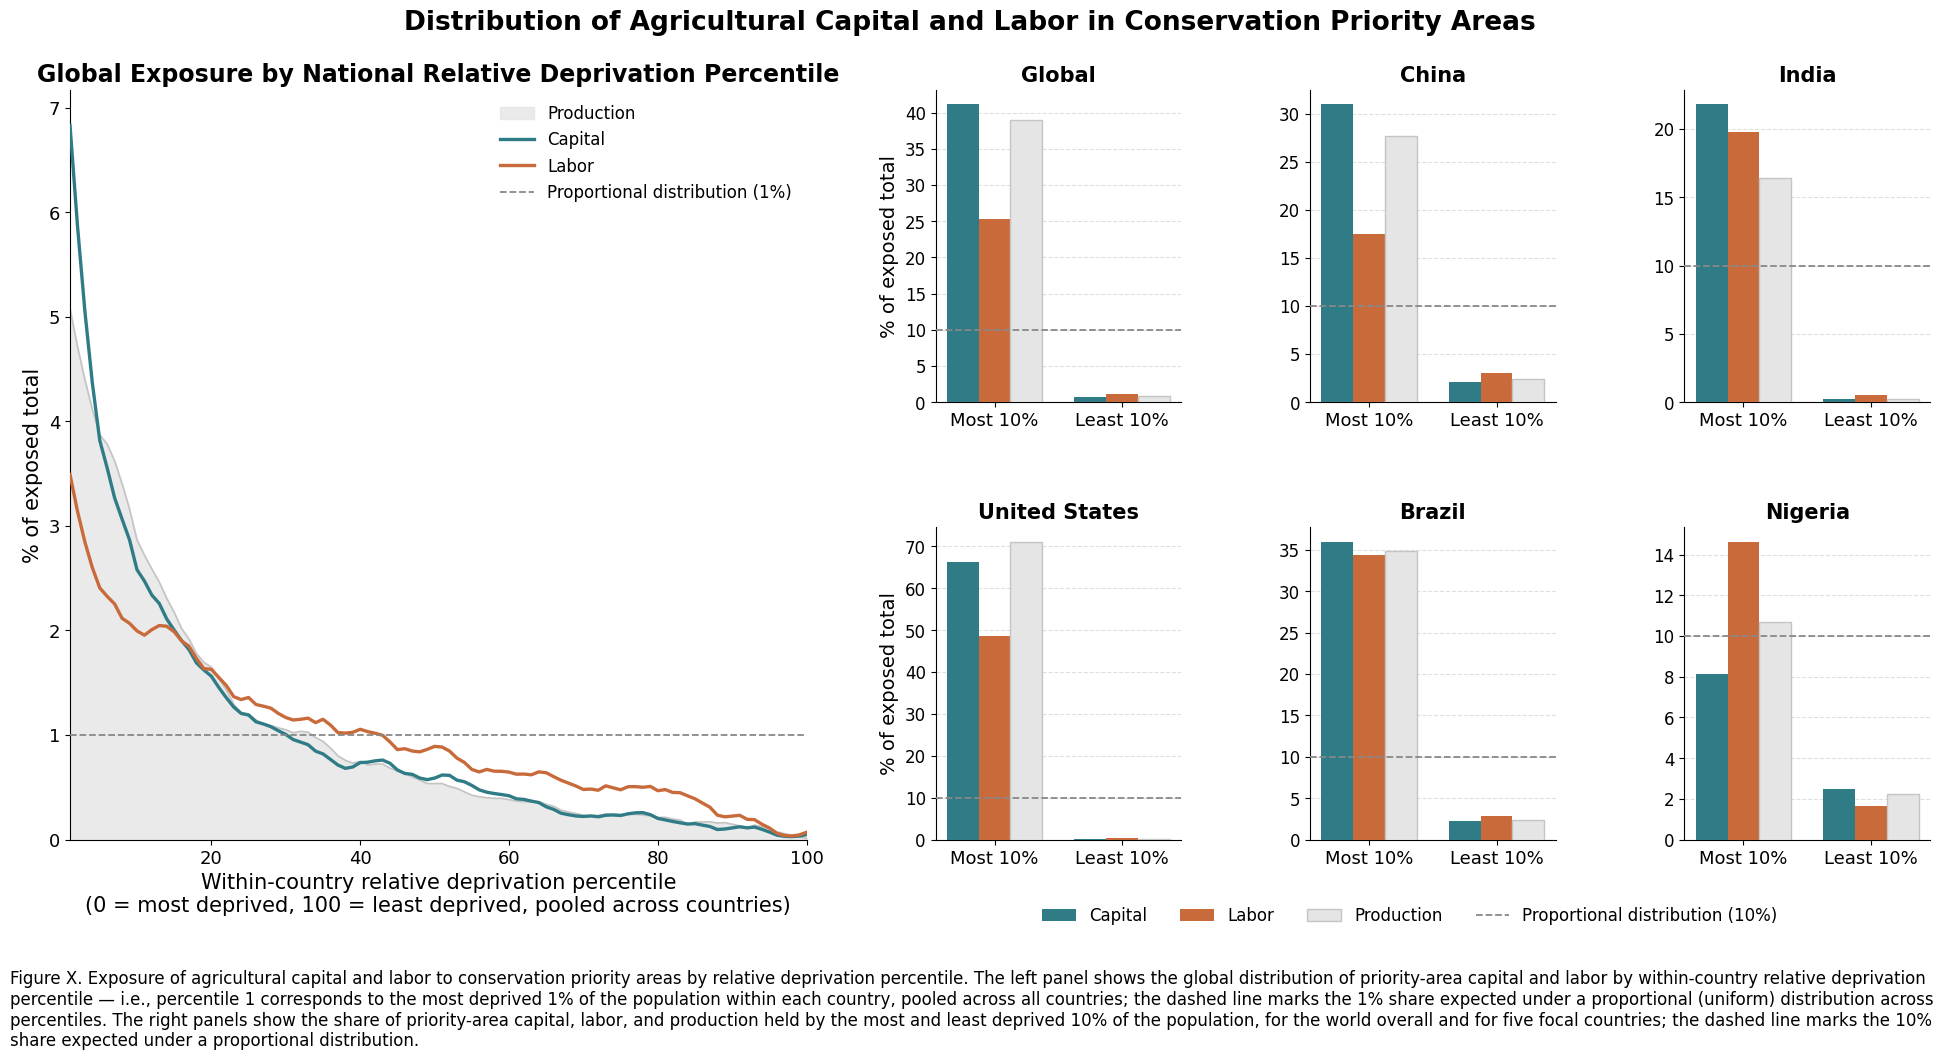

In [15]:
##### Plot exposure to capital/labor in priority areas by relative deprevation percentile (NATIONALLY DEFINED)
# country average infered for each country by where produciton is
# now with a "proportional distribution" reference line (1% for line chart, 10% for bar panels)

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"
REFERENCE_COLOR = "#888888"

country_mask_cache = {}

def get_country_mask(gid0, target_da=rd_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask

##### Plot exposure to capital/labor in priority areas by income percentile

def plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names=None,     # optional dict, e.g. {"CHN": "China", "IND": "India", ...}
    global_percentile_scope='global',
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    priority_da = biodiversity_da
    priority_mask_full = priority_da.squeeze().values >= 1

    def build_mask(gid0=None):
        mask = get_country_mask(gid0) if gid0 is not None else np.ones_like(priority_mask_full, dtype=bool)
        mask = mask & priority_mask_full
        return mask

    percentile_groups = {
        "Most 10%": range(1, 11),
        "Least 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")
        ax.axhline(10, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontweight="bold", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 4, width_ratios=[3, 1, 1, 1], wspace=0.35, hspace=0.4)

    # ---- Left: within-country percentile exposure pooled globally, capital + labor (line chart) ----
    ax_left = fig.add_subplot(gs[:, 0])

    pctl_da_global = percentile_lookup_rd[global_percentile_scope]
    mask_global = build_mask(gid0=None)

    capital_pct_line     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global))
    labor_pct_line       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global))
    production_pct_line  = smooth(pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global))

    ax_left.fill_between(
        production_pct_line.index, production_pct_line.values,
        color=COLORS["Production"], alpha=0.8, zorder=1, label="Production",
    )
    ax_left.plot(
        production_pct_line.index, production_pct_line.values,
        color=PRODUCTION_EDGE, linewidth=1.2, zorder=2,
    )

    ax_left.plot(capital_pct_line.index, capital_pct_line.values, label="Capital",
                 color=COLORS["Capital"], linewidth=2.4, zorder=4)
    ax_left.plot(labor_pct_line.index, labor_pct_line.values, label="Labor",
                 color=COLORS["Labor"], linewidth=2.4, zorder=4)
    ax_left.axhline(1, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4,
                     label="Proportional distribution (1%)")

    ax_left.set_xlabel(
        "Within-country relative deprivation percentile\n(0 = most deprived, 100 = least deprived, pooled across countries)",
        fontsize=15
    )
    ax_left.set_ylabel("% of exposed total", fontsize=15)
    ax_left.set_ylim(bottom=0)
    ax_left.set_xlim(1, 100)
    ax_left.tick_params(axis="both", labelsize=13)
    ax_left.spines[["top", "right"]].set_visible(False)
    ax_left.set_title(f"Global Exposure by National Relative Deprivation Percentile", fontweight="bold", fontsize=17)
    ax_left.legend(frameon=False, fontsize=12)

    # ---- Right: 2x3 grid — global panel + 5 country panels, bottom/top 10% bars ----
    right_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
    ]

    pctl_da_country = percentile_lookup_rd[country_percentile_scope]

    # -- Global panel: bars = modeled capital/labor/production --
    ax_global = right_axes[0]

    capital_pct     = pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global)
    labor_pct       = pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global)
    production_pct  = pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global)

    capital_vals     = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    labor_vals       = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    production_vals  = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

    ax_global.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3)
    ax_global.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3)
    ax_global.bar(x + width, production_vals, width, color=COLORS["Production"],
                  edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3)
    ax_global.axhline(10, color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", zorder=4)
    ax_global.set_xticks(x)
    ax_global.set_xticklabels(group_names, fontsize=13)
    ax_global.tick_params(axis="y", labelsize=12)
    ax_global.set_title("Global", fontweight="bold", fontsize=15)
    ax_global.spines[["top", "right"]].set_visible(False)
    ax_global.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax_global.set_axisbelow(True)

    # -- Country panels: bars = modeled capital/labor/production --
    for ax, gid0 in zip(right_axes[1:], countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    for ax in [right_axes[0], right_axes[3]]:
        ax.set_ylabel("% of exposed total", fontsize=14)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
        Line2D([0], [0], color=REFERENCE_COLOR, linewidth=1.3, linestyle="--", label="Proportional distribution (10%)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.72, 0.05), frameon=False, fontsize=12)

    fig.suptitle(f"Distribution of Agricultural Capital and Labor in Conservation Priority Areas",
                 fontweight="bold", fontsize=19, y=0.98)

    fig.text(
        0.02,
        0.02,
        "Figure X. Exposure of agricultural capital and labor to conservation priority areas by "
        "relative deprivation percentile. The left panel shows the global distribution of priority-area capital "
        "and labor by within-country relative deprivation percentile — i.e., percentile 1 corresponds to the most "
        "deprived 1% of the population within each country, pooled across all countries; the dashed line marks the "
        "1% share expected under a proportional (uniform) distribution across percentiles. The right panels show the "
        "share of priority-area capital, labor, and production held by the most and least deprived 10% of the "
        "population, for the world overall and for five focal countries; the dashed line marks the 10% share expected "
        "under a proportional distribution.",
        ha="left",
        va="top",
        fontsize=12,
        wrap=True,
    )

    fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.15, wspace=0.35, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/exposure_priority_relative_dperevation_national.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot — left panel now uses NATIONAL percentiles pooled globally
# (percentile 1 = most-deprived 1% *within each country*, not globally)
plot_capital_labor_exposure_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names={"CHN": "China", "IND": "India", "USA": "United States", "BRA": "Brazil", "NGA": "Nigeria"},
    global_percentile_scope='national',
    country_percentile_scope='national',
);

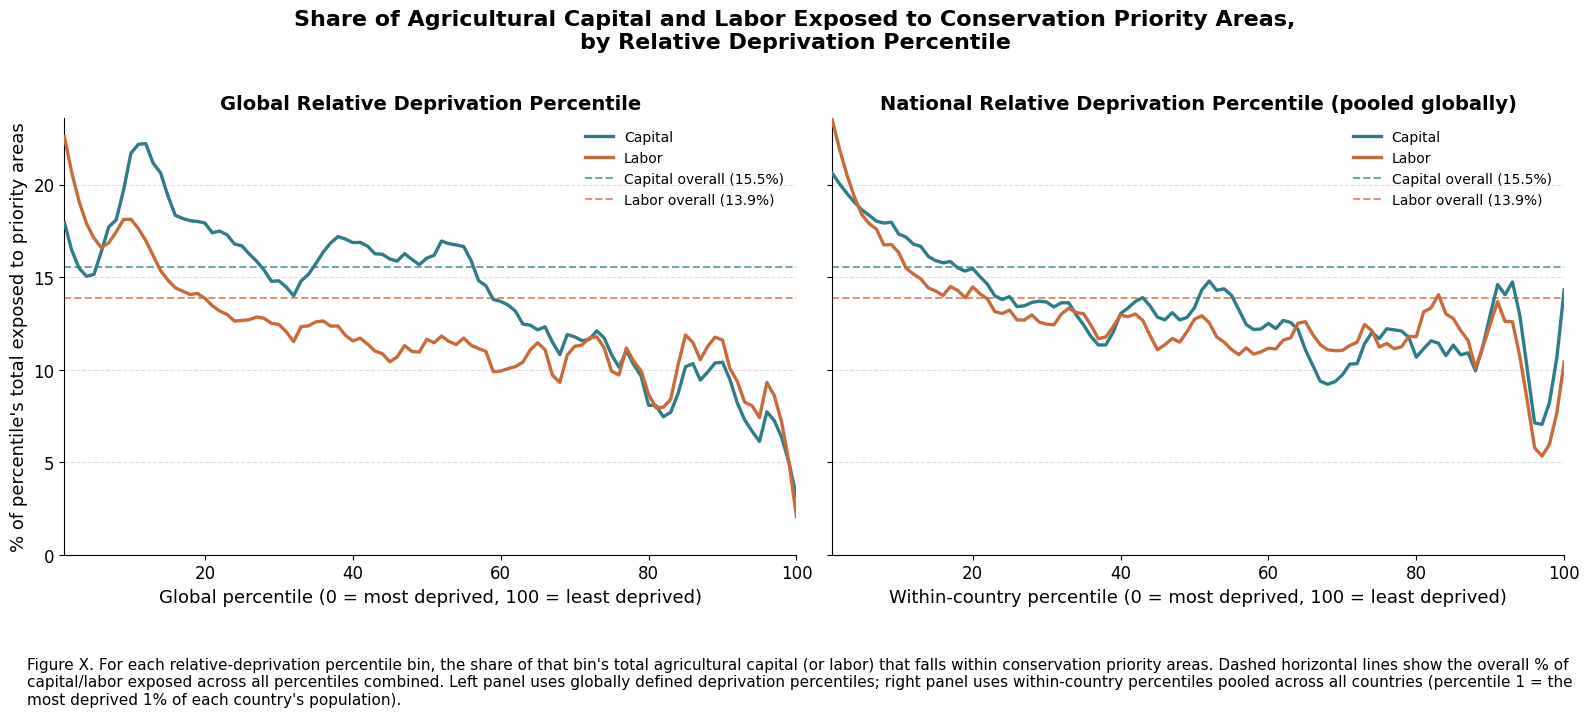

In [11]:
##### % of each percentile's capital/labor that is exposed to priority areas
# now with a horizontal reference line for the overall global total % exposed

def pct_exposed_by_percentile(var_da, pctl_da, priority_mask):
    """For each percentile bin (1-100), what % of that bin's total var is inside the priority mask.
    Also returns the overall % exposed across all valid pixels (for a reference line)."""
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = (~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100))

    var_v   = var[valid]
    pctl_v  = np.round(pctl[valid]).astype(int)
    mask_v  = priority_mask[valid]

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v, "exposed": mask_v})

    total_by_pctl   = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)
    exposed_by_pctl = (
        df[df["exposed"]]
        .groupby("percentile")["value"]
        .sum()
        .reindex(range(1, 101), fill_value=0)
    )

    pct = (exposed_by_pctl / total_by_pctl) * 100
    pct = pct.fillna(0)

    overall_total   = df["value"].sum()
    overall_exposed = df.loc[df["exposed"], "value"].sum()
    overall_pct     = (overall_exposed / overall_total) * 100 if overall_total > 0 else np.nan

    return pct, overall_pct


def plot_pct_exposed_by_deprivation(save=True):
    priority_da = biodiversity_da
    priority_mask = priority_da.squeeze().values >= 1

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    panels = [
        (axes[0], rd_global_da,   "Global Relative Deprivation Percentile",
         "Global percentile (0 = most deprived, 100 = least deprived)"),
        (axes[1], rd_national_da, "National Relative Deprivation Percentile (pooled globally)",
         "Within-country percentile (0 = most deprived, 100 = least deprived)"),
    ]

    for ax, pctl_da, title, xlabel in panels:
        capital_pct, capital_overall = pct_exposed_by_percentile(capital_da, pctl_da, priority_mask)
        labor_pct, labor_overall     = pct_exposed_by_percentile(labor_da, pctl_da, priority_mask)

        capital_pct_smooth = smooth(capital_pct)
        labor_pct_smooth   = smooth(labor_pct)

        ax.plot(capital_pct_smooth.index, capital_pct_smooth.values, label="Capital",
                color=COLORS["Capital"], linewidth=2.4, zorder=3)
        ax.plot(labor_pct_smooth.index, labor_pct_smooth.values, label="Labor",
                color=COLORS["Labor"], linewidth=2.4, zorder=3)

        # horizontal reference lines: overall global % exposed
        ax.axhline(capital_overall, color=COLORS["Capital"], linewidth=1.4,
                   linestyle="--", alpha=0.7, zorder=2,
                   label=f"Capital overall ({capital_overall:.1f}%)")
        ax.axhline(labor_overall, color=COLORS["Labor"], linewidth=1.4,
                   linestyle="--", alpha=0.7, zorder=2,
                   label=f"Labor overall ({labor_overall:.1f}%)")

        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_xlim(1, 100)
        ax.set_ylim(bottom=0)
        ax.tick_params(axis="both", labelsize=12)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)
        ax.set_title(title, fontweight="bold", fontsize=14)
        ax.legend(frameon=False, fontsize=10, loc="upper right")

    axes[0].set_ylabel("% of percentile's total exposed to priority areas", fontsize=13)

    fig.suptitle(
        "Share of Agricultural Capital and Labor Exposed to Conservation Priority Areas,\nby Relative Deprivation Percentile",
        fontweight="bold", fontsize=16, y=1.02,
    )

    fig.text(
        0.02, -0.06,
        "Figure X. For each relative-deprivation percentile bin, the share of that bin's total agricultural "
        "capital (or labor) that falls within conservation priority areas. Dashed horizontal lines show the "
        "overall % of capital/labor exposed across all percentiles combined. Left panel uses globally defined "
        "deprivation percentiles; right panel uses within-country percentiles pooled across all countries "
        "(percentile 1 = the most deprived 1% of each country's population).",
        ha="left", va="top", fontsize=11, wrap=True,
    )

    fig.tight_layout()

    if save:
        plt.savefig(f"{fd}/pct_exposed_by_deprivation.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


plot_pct_exposed_by_deprivation();

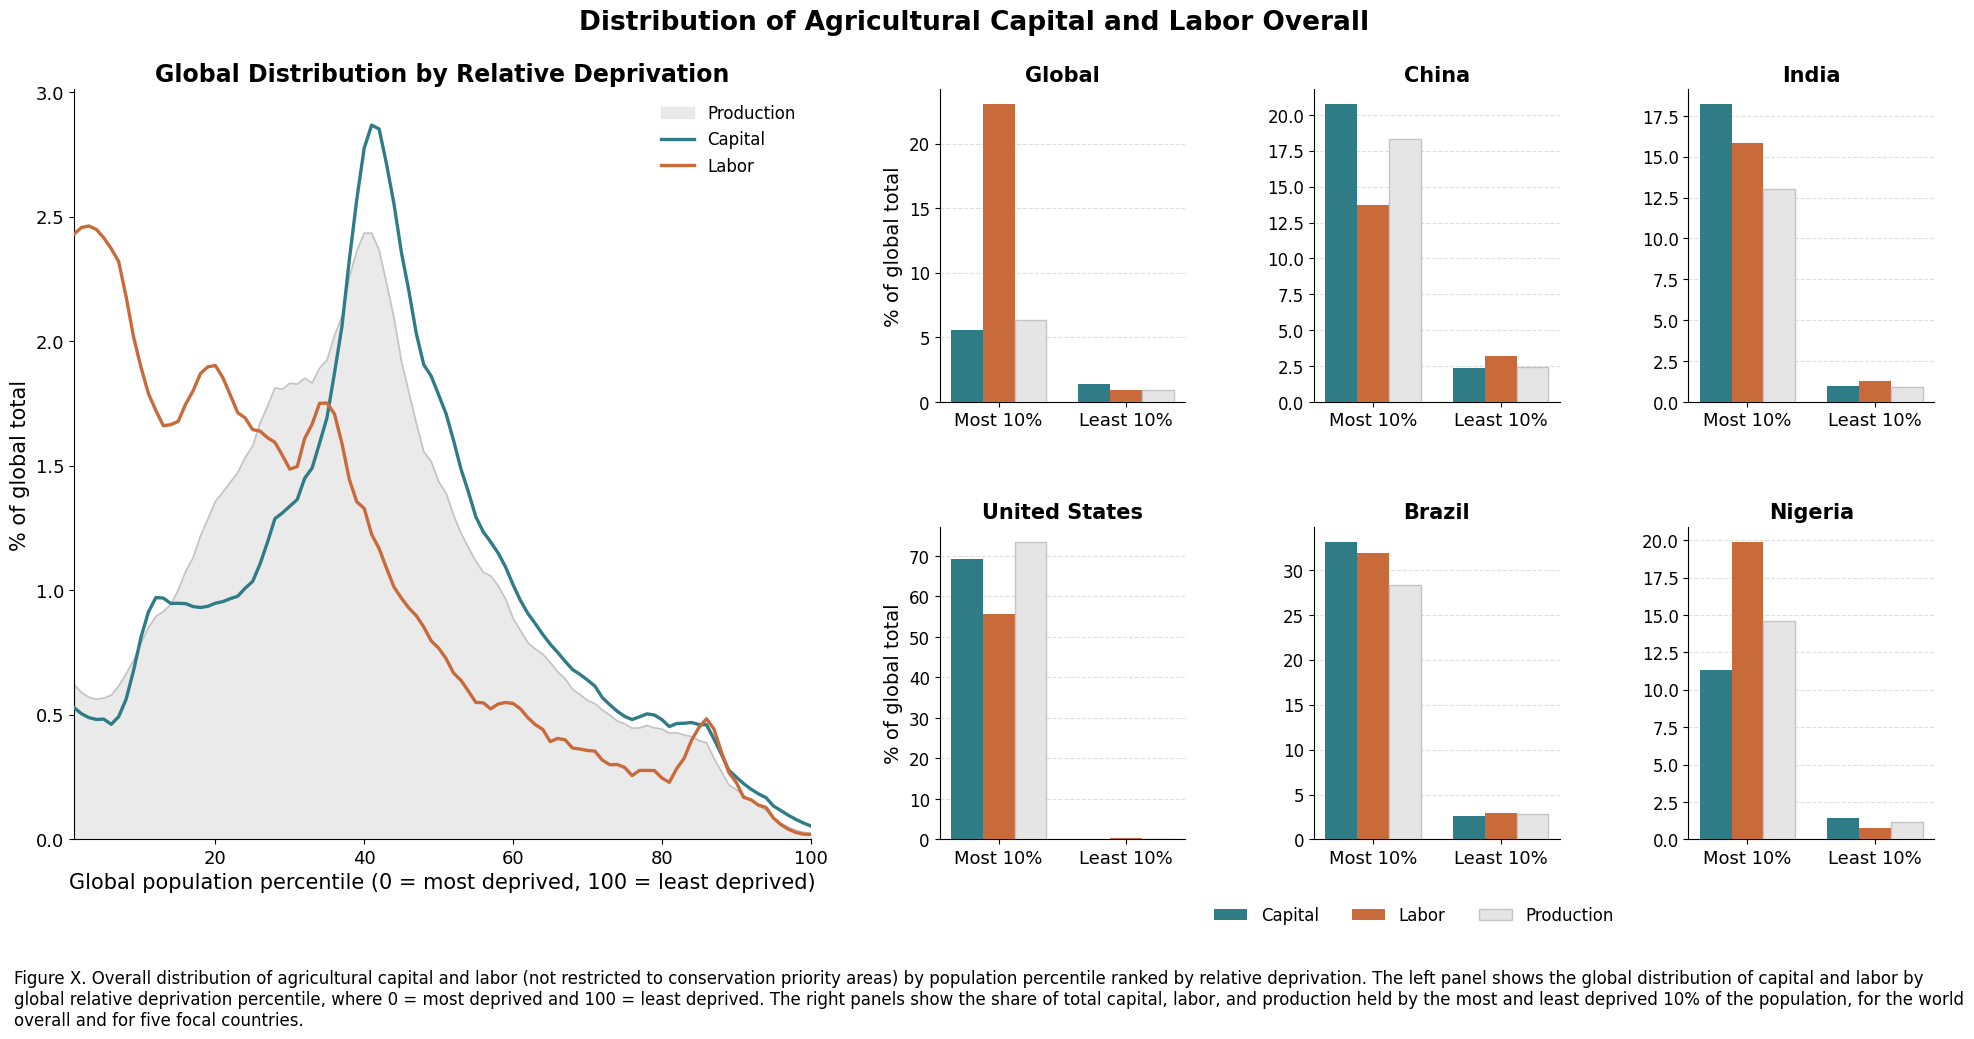

In [13]:
##### Plot overall capital/labor/production by relative deprivation percentile (GLOBAL scope, no country average)

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"

country_mask_cache = {}

def get_country_mask(gid0, target_da=rd_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask

##### Plot overall capital/labor/production by relative deprivation percentile

def plot_capital_labor_overall_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names=None,     # optional dict, e.g. {"CHN": "China", "IND": "India", ...}
    global_percentile_scope='global',
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    def build_mask(gid0=None):
        if gid0 is not None:
            return get_country_mask(gid0)
        return np.ones_like(get_country_mask(countries[0]), dtype=bool)

    percentile_groups = {
        "Most 10%": range(1, 11),
        "Least 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontweight="bold", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 4, width_ratios=[3, 1, 1, 1], wspace=0.35, hspace=0.4)

    # ---- Left: global-percentile distribution, capital + labor (line chart) ----
    ax_left = fig.add_subplot(gs[:, 0])

    pctl_da_global = percentile_lookup_rd[global_percentile_scope]
    mask_global = build_mask(gid0=None)

    capital_pct_line     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global))
    labor_pct_line       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global))
    production_pct_line  = smooth(pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global))

    ax_left.fill_between(
        production_pct_line.index, production_pct_line.values,
        color=COLORS["Production"], alpha=0.8, zorder=1, label="Production",
    )
    ax_left.plot(
        production_pct_line.index, production_pct_line.values,
        color=PRODUCTION_EDGE, linewidth=1.2, zorder=2,
    )

    ax_left.plot(capital_pct_line.index, capital_pct_line.values, label="Capital",
                 color=COLORS["Capital"], linewidth=2.4, zorder=4)
    ax_left.plot(labor_pct_line.index, labor_pct_line.values, label="Labor",
                 color=COLORS["Labor"], linewidth=2.4, zorder=4)

    ax_left.set_xlabel(f"Global population percentile (0 = most deprived, 100 = least deprived)", fontsize=15)
    ax_left.set_ylabel("% of global total", fontsize=15)
    ax_left.set_ylim(bottom=0)
    ax_left.set_xlim(1, 100)
    ax_left.tick_params(axis="both", labelsize=13)
    ax_left.spines[["top", "right"]].set_visible(False)
    ax_left.set_title(f"Global Distribution by Relative Deprivation", fontweight="bold", fontsize=17)
    ax_left.legend(frameon=False, fontsize=12)

    # ---- Right: 2x3 grid — global panel + 5 country panels, bottom/top 10% bars ----
    right_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
    ]

    pctl_da_country = percentile_lookup_rd[country_percentile_scope]

    # -- Global panel: bars = modeled capital/labor/production --
    ax_global = right_axes[0]

    capital_pct     = pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global)
    labor_pct       = pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global)
    production_pct  = pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global)

    capital_vals     = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    labor_vals       = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    production_vals  = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

    ax_global.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3)
    ax_global.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3)
    ax_global.bar(x + width, production_vals, width, color=COLORS["Production"],
                  edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3)
    ax_global.set_xticks(x)
    ax_global.set_xticklabels(group_names, fontsize=13)
    ax_global.tick_params(axis="y", labelsize=12)
    ax_global.set_title("Global", fontweight="bold", fontsize=15)
    ax_global.spines[["top", "right"]].set_visible(False)
    ax_global.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax_global.set_axisbelow(True)

    # -- Country panels: bars = modeled capital/labor/production --
    for ax, gid0 in zip(right_axes[1:], countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    for ax in [right_axes[0], right_axes[3]]:
        ax.set_ylabel("% of global total", fontsize=14)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.72, 0.05), frameon=False, fontsize=12)

    fig.suptitle(f"Distribution of Agricultural Capital and Labor Overall",
                 fontweight="bold", fontsize=19, y=0.98)

    fig.text(
        0.02,
        0.02,
        "Figure X. Overall distribution of agricultural capital and labor (not restricted to conservation "
        "priority areas) by population percentile ranked by relative deprivation. The left panel shows the global "
        "distribution of capital and labor by global relative deprivation percentile, where 0 = most deprived and "
        "100 = least deprived. The right panels show the share of total capital, labor, and production held by "
        "the most and least deprived 10% of the population, for the world overall and for five focal countries.",
        ha="left",
        va="top",
        fontsize=12,
        wrap=True,
    )

    fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.15, wspace=0.35, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/overall_capital_labor_relative_deprivation.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot
plot_capital_labor_overall_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names={"CHN": "China", "IND": "India", "USA": "United States", "BRA": "Brazil", "NGA": "Nigeria"},
);

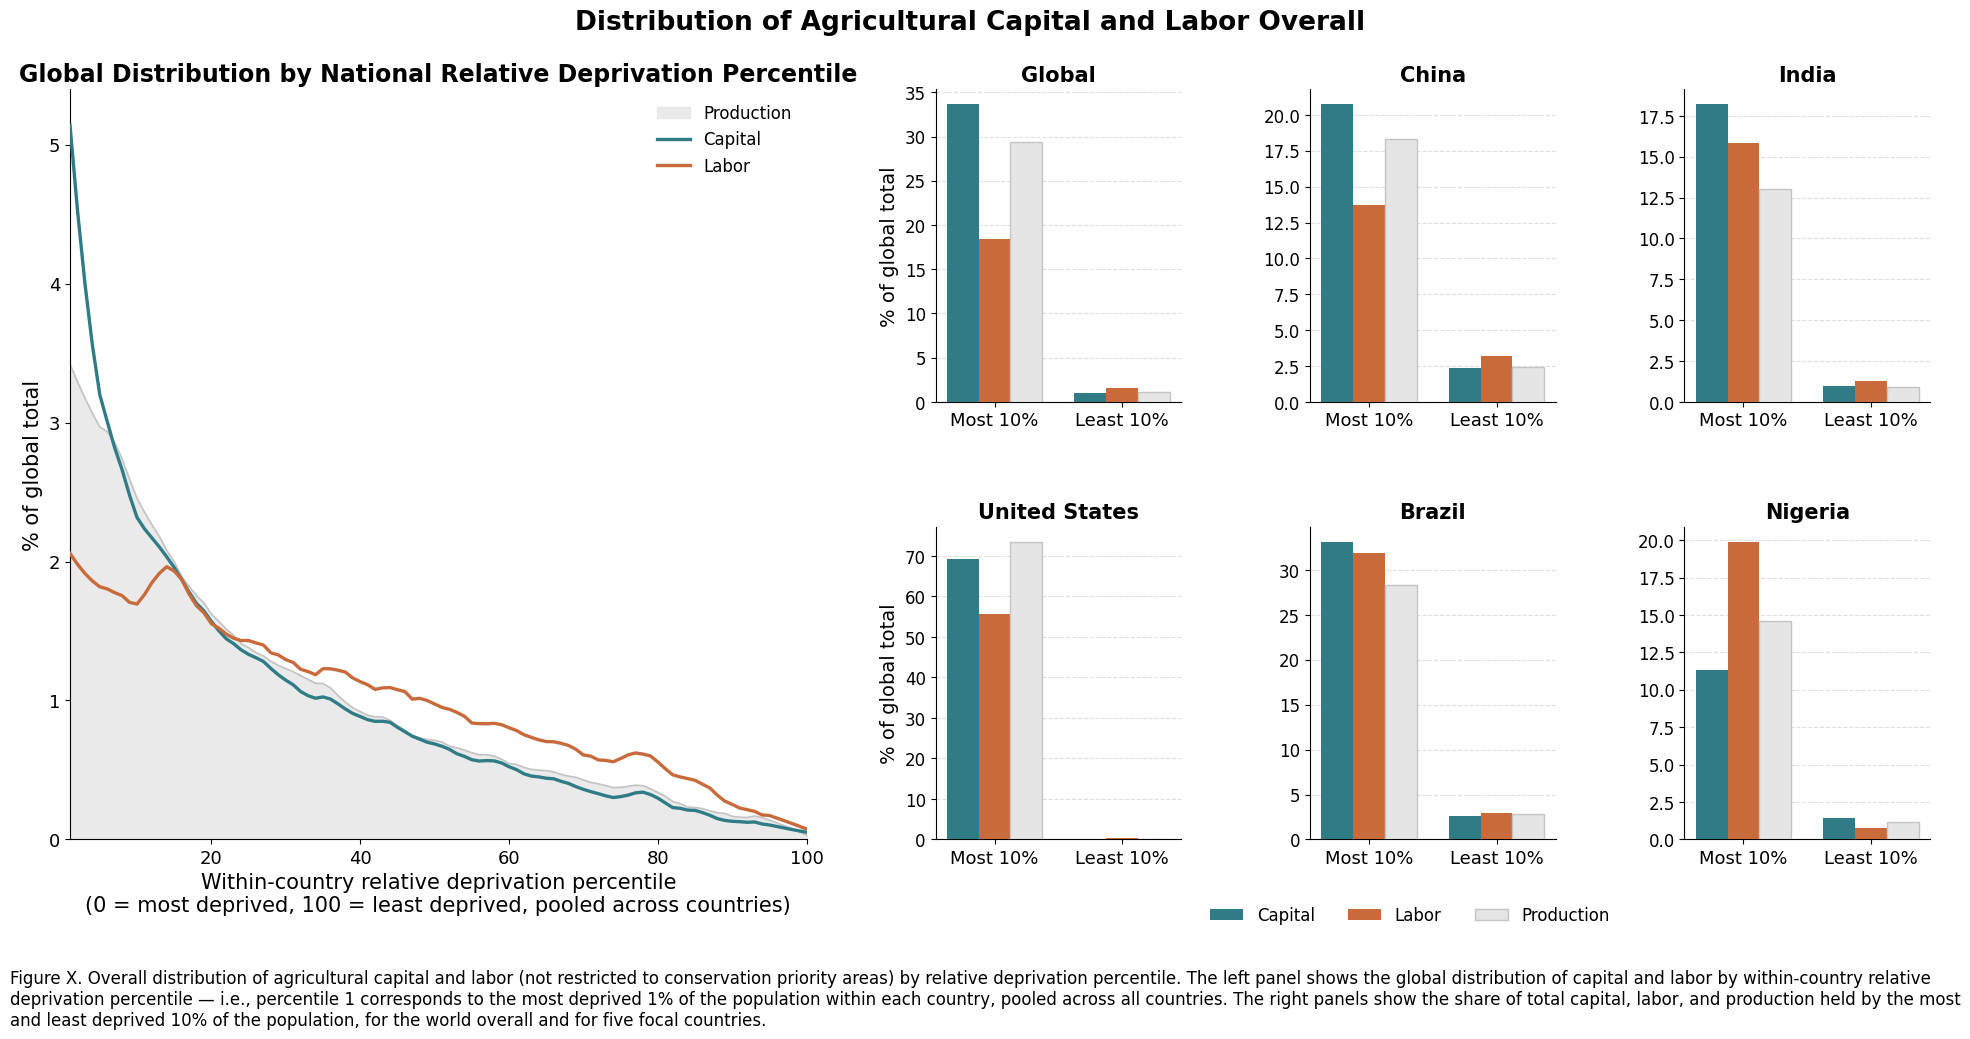

In [12]:
##### Plot overall capital/labor/production by relative deprivation percentile (NATIONALLY DEFINED)
# same structure as the exposure version, but NOT restricted to priority areas — this is the full distribution

COLORS = {
    "Capital": "#2F7C87",
    "Labor": "#C96A3B",
    "Production": "#E5E5E5",
}
PRODUCTION_EDGE = "#C4C4C4"

country_mask_cache = {}

def get_country_mask(gid0, target_da=rd_national_da):
    """Rasterize a single country's outline onto the common reference grid."""
    if gid0 in country_mask_cache:
        return country_mask_cache[gid0]

    geom = country_shp[country_shp['GID_0'] == gid0]
    if geom.empty:
        raise ValueError(f"No country found with GID_0 == '{gid0}'. "
                          f"Check country_shp['GID_0'].unique() for valid codes.")

    geom_proj = geom.to_crs(target_da.rio.crs)
    transform = target_da.rio.transform()
    out_shape = target_da.squeeze().shape

    mask = rasterio.features.geometry_mask(
        geom_proj.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )

    country_mask_cache[gid0] = mask
    return mask

##### Plot overall capital/labor/production by relative deprivation percentile

def plot_capital_labor_overall_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names=None,     # optional dict, e.g. {"CHN": "China", "IND": "India", ...}
    global_percentile_scope='national',
    country_percentile_scope='national',
    save=True,
):
    if country_names is None:
        country_names = {}

    def build_mask(gid0=None):
        if gid0 is not None:
            return get_country_mask(gid0)
        # no country restriction, no priority-area restriction — just needs a shape reference
        return np.ones_like(get_country_mask(countries[0]), dtype=bool)

    percentile_groups = {
        "Most 10%": range(1, 11),
        "Least 10%": range(91, 101),
    }
    group_names = list(percentile_groups.keys())
    x = np.arange(len(group_names))
    width = 0.25

    def draw_bar_panel(ax, capital_vals, labor_vals, production_vals, title):
        ax.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3, label="Capital")
        ax.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3, label="Labor")
        ax.bar(x + width, production_vals, width, color=COLORS["Production"],
               edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3, label="Production")

        ax.set_xticks(x)
        ax.set_xticklabels(group_names, fontsize=13)
        ax.tick_params(axis="y", labelsize=12)
        ax.set_title(title, fontweight="bold", fontsize=15)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 4, width_ratios=[3, 1, 1, 1], wspace=0.35, hspace=0.4)

    # ---- Left: within-country percentile distribution pooled globally, capital + labor (line chart) ----
    ax_left = fig.add_subplot(gs[:, 0])

    pctl_da_global = percentile_lookup_rd[global_percentile_scope]
    mask_global = build_mask(gid0=None)

    capital_pct_line     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global))
    labor_pct_line       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global))
    production_pct_line  = smooth(pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global))

    ax_left.fill_between(
        production_pct_line.index, production_pct_line.values,
        color=COLORS["Production"], alpha=0.8, zorder=1, label="Production",
    )
    ax_left.plot(
        production_pct_line.index, production_pct_line.values,
        color=PRODUCTION_EDGE, linewidth=1.2, zorder=2,
    )

    ax_left.plot(capital_pct_line.index, capital_pct_line.values, label="Capital",
                 color=COLORS["Capital"], linewidth=2.4, zorder=4)
    ax_left.plot(labor_pct_line.index, labor_pct_line.values, label="Labor",
                 color=COLORS["Labor"], linewidth=2.4, zorder=4)

    ax_left.set_xlabel(
        "Within-country relative deprivation percentile\n(0 = most deprived, 100 = least deprived, pooled across countries)",
        fontsize=15
    )
    ax_left.set_ylabel("% of global total", fontsize=15)
    ax_left.set_ylim(bottom=0)
    ax_left.set_xlim(1, 100)
    ax_left.tick_params(axis="both", labelsize=13)
    ax_left.spines[["top", "right"]].set_visible(False)
    ax_left.set_title(f"Global Distribution by National Relative Deprivation Percentile", fontweight="bold", fontsize=17)
    ax_left.legend(frameon=False, fontsize=12)

    # ---- Right: 2x3 grid — global panel + 5 country panels, bottom/top 10% bars ----
    right_axes = [
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
        fig.add_subplot(gs[1, 3]),
    ]

    pctl_da_country = percentile_lookup_rd[country_percentile_scope]

    # -- Global panel: bars = modeled capital/labor/production --
    ax_global = right_axes[0]

    capital_pct     = pct_by_percentile_within_mask(capital_da, pctl_da_global, mask_global)
    labor_pct       = pct_by_percentile_within_mask(labor_da, pctl_da_global, mask_global)
    production_pct  = pct_by_percentile_within_mask(production_da, pctl_da_global, mask_global)

    capital_vals     = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    labor_vals       = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
    production_vals  = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

    ax_global.bar(x - width, capital_vals, width, color=COLORS["Capital"], zorder=3)
    ax_global.bar(x, labor_vals, width, color=COLORS["Labor"], zorder=3)
    ax_global.bar(x + width, production_vals, width, color=COLORS["Production"],
                  edgecolor=PRODUCTION_EDGE, linewidth=1, zorder=3)
    ax_global.set_xticks(x)
    ax_global.set_xticklabels(group_names, fontsize=13)
    ax_global.tick_params(axis="y", labelsize=12)
    ax_global.set_title("Global", fontweight="bold", fontsize=15)
    ax_global.spines[["top", "right"]].set_visible(False)
    ax_global.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
    ax_global.set_axisbelow(True)

    # -- Country panels: bars = modeled capital/labor/production --
    for ax, gid0 in zip(right_axes[1:], countries):
        country_mask = build_mask(gid0)

        capital_pct    = pct_by_percentile_within_mask(capital_da, pctl_da_country, country_mask)
        labor_pct      = pct_by_percentile_within_mask(labor_da, pctl_da_country, country_mask)
        production_pct = pct_by_percentile_within_mask(production_da, pctl_da_country, country_mask)

        capital_vals    = [capital_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        labor_vals      = [labor_pct.loc[list(r)].sum() for r in percentile_groups.values()]
        production_vals = [production_pct.loc[list(r)].sum() for r in percentile_groups.values()]

        panel_title = country_names.get(gid0, gid0)
        draw_bar_panel(ax, capital_vals, labor_vals, production_vals, panel_title)

    for ax in [right_axes[0], right_axes[3]]:
        ax.set_ylabel("% of global total", fontsize=14)

    handles = [
        Patch(facecolor=COLORS["Capital"], label="Capital"),
        Patch(facecolor=COLORS["Labor"], label="Labor"),
        Patch(facecolor=COLORS["Production"], edgecolor=PRODUCTION_EDGE, label="Production"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=3,
               bbox_to_anchor=(0.72, 0.05), frameon=False, fontsize=12)

    fig.suptitle(f"Distribution of Agricultural Capital and Labor Overall",
                 fontweight="bold", fontsize=19, y=0.98)

    fig.text(
        0.02,
        0.02,
        "Figure X. Overall distribution of agricultural capital and labor (not restricted to conservation "
        "priority areas) by relative deprivation percentile. The left panel shows the global distribution of "
        "capital and labor by within-country relative deprivation percentile — i.e., percentile 1 corresponds to "
        "the most deprived 1% of the population within each country, pooled across all countries. The right panels "
        "show the share of total capital, labor, and production held by the most and least deprived 10% of the "
        "population, for the world overall and for five focal countries.",
        ha="left",
        va="top",
        fontsize=12,
        wrap=True,
    )

    fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.15, wspace=0.35, hspace=0.4)

    if save:
        plt.savefig(f"{fd}/overall_capital_labor_relative_deprivation_national.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig

# Plot — overall (non-exposed) capital/labor/production by national deprivation percentile, pooled globally
plot_capital_labor_overall_combined(
    countries=("CHN", "IND", "USA", "BRA", "NGA"),
    country_names={"CHN": "China", "IND": "India", "USA": "United States", "BRA": "Brazil", "NGA": "Nigeria"},
    global_percentile_scope='national',
    country_percentile_scope='national',
);